# Phase 1
# Dataset Assembly

This assembles our complete dataset for 4 attributes:
1. **Color** (493 samples) : from Visual Counterfact dataset
2. **Size** (727 samples) : from Visual Counterfact dataset
3. **MMStar-Finegrined** (231) : From MMStar dataset
4. **MMStar-Coarse** (230) : From MMStar dataset
5. **Count** (synthetic) : curated from MMStar + manually sourced counterfactual images
6. **Shape** (synthetic) : curated from MMStar's single-instance attribute reasoning + manually sourced

**Output:** a single folder `arbitration_dataset/` containing all images + one unified `metadata.csv` that the next processing piepline reads directly.

### Visual Counterfact dataset
The paper's Color and Size samples come from the Visual-Counterfact dataset (Golovanevsky et al., 2025 — "Pixels versus Priors"). 
MMstar dataset (Chen et al., 2024).

## 0. Install

In [26]:
import sys
!{sys.executable} -m pip install -q datasets pillow numpy pandas matplotlib
print("done")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
done


## 1. Imports & configuration

In [ ]:
import os, json, csv, shutil, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# output directory structure
DATASET_DIR = Path("./arbitration_dataset")
IMAGES_DIR  = DATASET_DIR / "images"
META_PATH   = DATASET_DIR / "metadata.csv"

for attr in ["color", "size", "count", "shape"]:
    (IMAGES_DIR / attr).mkdir(parents=True, exist_ok=True)

print(f"dataset dir: {DATASET_DIR.resolve()}")
print("subdirs created: color, size, count, shape")

# metadata accumulator
# all sections append to this list; at the end we write one CSV
ALL_METADATA = []

def register_sample(sample_id, attribute, obj, question,
                    visual_answer, prior_answer,
                    cf_image_path, std_image_path, source):
    ALL_METADATA.append({
        "sample_id":      sample_id,
        "attribute":      attribute,
        "object":         obj,
        "question":       question,
        "visual_answer":  visual_answer,
        "prior_answer":   prior_answer,
        "cf_image":       str(cf_image_path),
        "std_image":      str(std_image_path),
        "source":         source,
    })

def save_image(img, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    img.save(str(path))
    return str(path)

print(f"metadata fields: {list(register_sample.__code__.co_varnames[:9])}")


# recolor utilities (from Phase 1, for fallback Color generation)
TARGET_HUE_PIL = {
    "red": 0, "orange": 21, "yellow": 42, "green": 85,
    "blue": 150, "purple": 200, "pink": 225, "brown": 15,
}

def dominant_hue(img, bins=32):
    hsv = np.asarray(img.convert("HSV")).astype(np.float64)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    mask = (s > 40) & (v > 30) & (v < 250)
    if mask.sum() == 0:
        return float(h.mean())
    hist, edges = np.histogram(h[mask], bins=bins, range=(0, 256))
    peak = np.argmax(hist)
    lo = edges[max(peak - 1, 0)]
    hi = edges[min(peak + 2, bins)]
    refined = h[mask][(h[mask] >= lo) & (h[mask] < hi)]
    if len(refined) == 0:
        return (edges[peak] + edges[peak + 1]) / 2
    ang = refined / 256 * 2 * np.pi
    mean_ang = np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())
    return (mean_ang / (2 * np.pi) * 256) % 256

def recolor_to_target(img, target_name):
    orig_hue = dominant_hue(img)
    shift = (TARGET_HUE_PIL[target_name] - orig_hue) % 256
    hsv = np.asarray(img.convert("HSV")).astype(np.int16)
    hsv[..., 0] = (hsv[..., 0] + int(shift)) % 256
    return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")

print("all utilities defined.")

dataset dir: /Users/ramangudewar/Seminar-MLU/FIanal Project/arbitration_dataset
subdirs created: color, size, count, shape
metadata fields: ['sample_id', 'attribute', 'obj', 'question', 'visual_answer', 'prior_answer', 'cf_image_path', 'std_image_path', 'source']
all utilities defined.


## Part 1 : Color & Size (Visual-Counterfact dataset)

The paper uses 493 Color + 727 Size counterfactual samples from the Visual-Counterfact dataset. Each sample has a counterfactual image (e.g. blue banana) and a standard image (normal yellow banana), plus metadata (object name, visual answer, prior answer).

This cell tries several HuggingFace identifiers. If none work, it prints manual download instructions.

In [ ]:
from huggingface_hub import login
login(token="hugging_face_token")  # I have removed my token for security reason. Please use token to login to Hugging Face Hub.

In [64]:
from datasets import load_dataset

vc_dataset = None
vc_candidates = [
    "mgolov/Visual-Counterfact",   # confirmed correct — put first
    "BrownUniversity/Visual-Counterfact",
    "WIGovern/Visual-Counterfact",
    "mgolovanevsky/visual_counterfact",
]

for name in vc_candidates:
    try:
        vc_dataset = load_dataset(name)   # trust_remote_code removed
        print(f"loaded '{name}'")
        break
    except Exception as e:
        print(f"  '{name}' failed: {e}")
        continue

if vc_dataset is not None:
    print(f"splits: {list(vc_dataset.keys())}")
    for split_name, split_data in vc_dataset.items():
        print(f"  {split_name}: {len(split_data)} samples, columns: {split_data.column_names}")
else:
    print("Visual-Counterfact NOT found on HuggingFace under any tried identifier.")

README.md:   0%|          | 0.00/2.69k [00:00<?, ?B/s]

data/color-00000-of-00001.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

data/size-00000-of-00001.parquet:   0%|          | 0.00/98.8M [00:00<?, ?B/s]

Generating color split:   0%|          | 0/493 [00:00<?, ? examples/s]

Generating size split:   0%|          | 0/727 [00:00<?, ? examples/s]

loaded 'mgolov/Visual-Counterfact'
splits: ['color', 'size']
  color: 493 samples, columns: ['correct_answer', 'incorrect_answer', 'object', 'original_image', 'counterfact_image']
  size: 727 samples, columns: ['correct_answer', 'incorrect_answer', 'object', 'original_image', 'counterfact_image']


### 1a. Process Color & Size splits

This cell processes whichever data source is available:
- **If Visual-Counterfact loaded:** extracts Color and Size splits, saves images, registers metadata
- **If not loaded:** check if you placed it manually at `./visual_counterfact_raw/`
- **Fallback:** skip to the fallback cell below for a small pilot-based Color set

In [71]:
color_count = 0
size_count = 0

def extract_answer(val):
    """Handle both string and list-wrapped answer fields."""
    if isinstance(val, list):
        val = val[0] if val else ""
    return str(val).lower().strip()

def process_vc_split(dataset_split, attribute, question_template):
    count = 0
    print(f"  processing {attribute} | columns: {dataset_split.column_names}")

    for i, row in enumerate(dataset_split):
        sid = f"{attribute}_{i+1:04d}"

        cf_img  = row.get("counterfact_image")
        std_img = row.get("original_image")
        obj_name = str(row.get("object", ""))

        # incorrect_answer = what's visually shown (counterfactual truth)
        # correct_answer   = the model's prior/world-knowledge expectation
        vis_ans = extract_answer(row.get("incorrect_answer", ""))
        pri_ans = extract_answer(row.get("correct_answer", ""))

        if cf_img is None or not isinstance(cf_img, Image.Image):
            continue

        cf_path = save_image(cf_img, IMAGES_DIR / attribute / f"{sid}_cf.png")
        std_path = ""
        if std_img is not None and isinstance(std_img, Image.Image):
            std_path = save_image(std_img, IMAGES_DIR / attribute / f"{sid}_std.png")

        question = question_template.format(object=obj_name) if obj_name else question_template.format(object="object")

        register_sample(sid, attribute, obj_name, question,
                       vis_ans, pri_ans, cf_path, std_path, "visual_counterfact")
        count += 1

    return count

if vc_dataset is not None:
    # try to find Color and Size splits
    # they might be separate splits, or a single split with an attribute column
    splits = list(vc_dataset.keys())

    if len(splits) >= 2:
        # separate splits: assume first=color, second=size (inspect to confirm)
        print(f"found {len(splits)} splits: {splits}")
        for split_name in splits:
            data = vc_dataset[split_name]
            n = len(data)
            if n < 600:  # Color has 493
                print(f"  {split_name} ({n} samples) -> treating as Color")
                color_count = process_vc_split(data, "color", "What color is the {object}?")
            else:        # Size has 727
                print(f"  {split_name} ({n} samples) -> treating as Size")
                size_count = process_vc_split(data, "size", "Which is bigger, the {object}?")
    elif len(splits) == 1:
        # single split: check for an attribute column
        data = vc_dataset[splits[0]]
        print(f"single split: {splits[0]} ({len(data)} samples)")
        print(f"columns: {data.column_names}")
        # look for attribute/type column to split
        attr_col = None
        for key in ["attribute", "type", "task", "split", "category"]:
            if key in data.column_names:
                attr_col = key; break
        if attr_col:
            vals = Counter(str(x) for x in data[attr_col])
            print(f"  attribute column '{attr_col}' values: {vals}")
            for val, cnt in vals.items():
                subset = data.filter(lambda x: str(x[attr_col]) == val)
                if "color" in val.lower() or "colour" in val.lower():
                    color_count = process_vc_split(subset, "color", "What color is the {object}?")
                elif "size" in val.lower():
                    size_count = process_vc_split(subset, "size", "Which is bigger, the {object}?")
        else:
            print("  no attribute column found — processing all as Color")
            color_count = process_vc_split(data, "color", "What color is the {object}?")

    print(f"\nProcessed: Color={color_count}, Size={size_count}")
else:
    print("Visual-Counterfact not loaded. Use the fallback cell below or download manually.")
    print(f"Current Color samples: {color_count}")
    print(f"Current Size samples: {size_count}")

found 2 splits: ['color', 'size']
  color (493 samples) -> treating as Color
  processing color | columns: ['correct_answer', 'incorrect_answer', 'object', 'original_image', 'counterfact_image']
  size (727 samples) -> treating as Size
  processing size | columns: ['correct_answer', 'incorrect_answer', 'object', 'original_image', 'counterfact_image']

Processed: Color=493, Size=727


In [75]:
sample = [m for m in ALL_METADATA if m["attribute"] == "color"][1]
print(sample)

{'sample_id': 'color_0002', 'attribute': 'color', 'object': 'tomato', 'question': 'What color is the tomato?', 'visual_answer': 'green', 'prior_answer': 'red', 'cf_image': 'arbitration_dataset/images/color/color_0002_cf.png', 'std_image': 'arbitration_dataset/images/color/color_0002_std.png', 'source': 'pilot_recolor'}


In [77]:
from collections import Counter

# keep only ONE copy of each source, and drop the pilot fallback since we have the real data now
seen_vc = set()
cleaned = []

for m in ALL_METADATA:
    if m["source"] == "visual_counterfact":
        if m["sample_id"] not in seen_vc:
            seen_vc.add(m["sample_id"])
            cleaned.append(m)
    elif m["source"] == "pilot_recolor":
        continue   # drop synthetic fallback now that real Visual-Counterfact data exists
    else:
        cleaned.append(m)   # keep count/shape as-is

ALL_METADATA = cleaned

print(f"total entries after cleanup: {len(ALL_METADATA)}")
print(Counter((m["attribute"], m["source"]) for m in ALL_METADATA))

total entries after cleanup: 1232
Counter({('size', 'visual_counterfact'): 727, ('color', 'visual_counterfact'): 493, ('count', 'manual_count'): 6, ('shape', 'manual_shape'): 6})


In [78]:
## Now the CSV file write

In [79]:
fieldnames = ["sample_id", "attribute", "object", "question",
              "visual_answer", "prior_answer", "cf_image", "std_image", "source"]

with open(META_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(ALL_METADATA)

print(f"metadata.csv written: {len(ALL_METADATA)} samples")

metadata.csv written: 1232 samples


## Part 2 : Load MMStar 

MMStar contains natural images with perception/reasoning questions. We'll filter it for:
- **Object counting** subcategory → reference material for Count attribute
- **Single-instance attribute reasoning** subcategory → reference material for Shape attribute

These are NOT counterfactual images — they're normal images that we'll use as a starting point or reference for curating our counterfactual sets.

In [53]:
from datasets import load_dataset

mmstar = load_dataset("Lin-Chen/MMStar", split="val")
print(f"loaded MMStar: {len(mmstar)} samples")
print(f"columns: {mmstar.column_names}")

# find the category column
cat_col = None
for c in ["category", "l2_category", "meta_info"]:
    if c in mmstar.column_names:
        cat_col = c; break

if cat_col:
    cats = Counter(str(x) for x in mmstar[cat_col])
    print(f"\ncategory column: '{cat_col}'")
    print("distribution:")
    for k, v in cats.most_common():
        print(f"  {k:45s} {v:4d}")
else:
    print("no category column found — listing all columns for manual inspection")
    for c in mmstar.column_names:
        vals = mmstar[c][:3]
        print(f"  {c}: {vals}")

loaded MMStar: 1500 samples
columns: ['index', 'question', 'image', 'answer', 'category', 'l2_category', 'meta_info']

category column: 'category'
distribution:
  coarse perception                              250
  fine-grained perception                        250
  instance reasoning                             250
  logical reasoning                              250
  math                                           250
  science & technology                           250


### 2a. Filter MMStar for Count-related samples

found 160 counting-related samples in MMStar


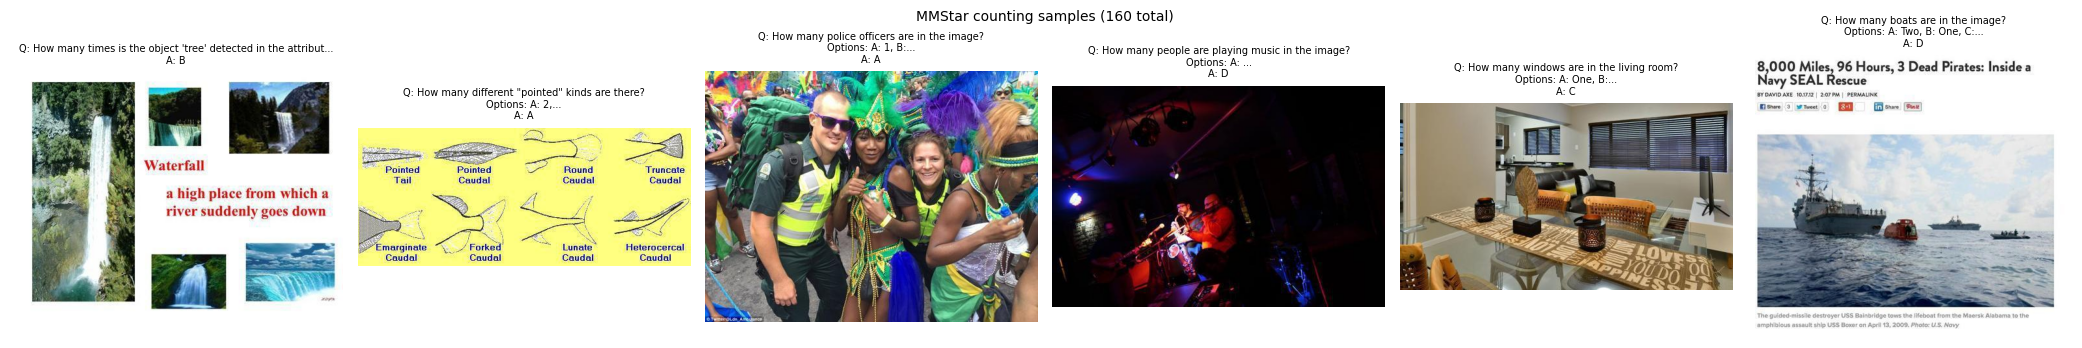

In [54]:
# filter for counting-related samples
count_keywords = ["count", "counting", "how many", "number of"]
count_samples = []

for i in range(len(mmstar)):
    row = mmstar[i]
    cat = str(row.get(cat_col, "")).lower() if cat_col else ""
    question = str(row.get("question", "")).lower()

    is_count = any(kw in cat for kw in count_keywords) or "how many" in question

    if is_count:
        count_samples.append(row)

print(f"found {len(count_samples)} counting-related samples in MMStar")

# display a few
show_n = min(6, len(count_samples))
if show_n > 0:
    fig, axes = plt.subplots(1, show_n, figsize=(3.5 * show_n, 3.5))
    if show_n == 1:
        axes = [axes]
    for j in range(show_n):
        row = count_samples[j]
        img = row.get("image")
        q = str(row.get("question", ""))[:60]
        a = str(row.get("answer", ""))[:20]
        if isinstance(img, Image.Image):
            axes[j].imshow(img)
        axes[j].set_title(f"Q: {q}...\nA: {a}", fontsize=7)
        axes[j].axis("off")
    plt.suptitle(f"MMStar counting samples ({len(count_samples)} total)", fontsize=10)
    plt.tight_layout()
    plt.savefig(DATASET_DIR / "mmstar_count_samples.png", dpi=110)
    plt.show()

### 2b. Filter MMStar for Shape/attribute-related samples

found 89 shape/attribute-related samples in MMStar


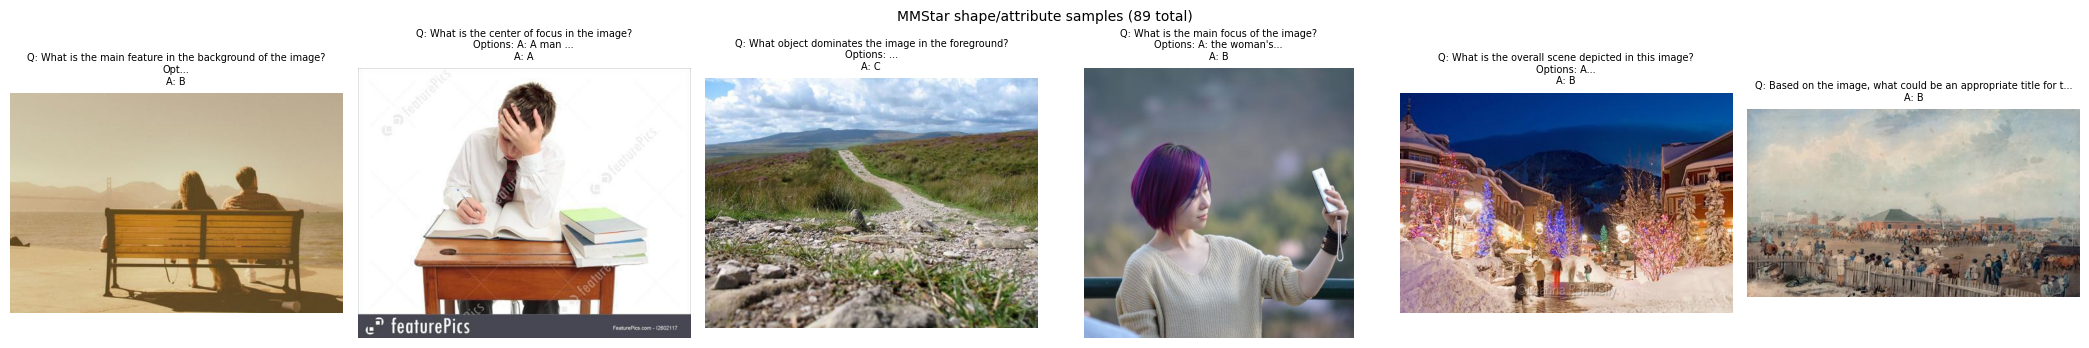

In [55]:
# filter for single-instance attribute reasoning (shape-focused)
shape_keywords = ["attribute", "single-instance", "shape", "form", "appearance"]
shape_samples = []

for i in range(len(mmstar)):
    row = mmstar[i]
    cat = str(row.get(cat_col, "")).lower() if cat_col else ""
    question = str(row.get("question", "")).lower()

    is_shape = any(kw in cat for kw in shape_keywords)
    # also catch shape-specific questions even if category doesn't match
    if not is_shape:
        is_shape = any(kw in question for kw in ["shape", "shaped", "round", "square",
                                                   "rectangular", "circular", "flat"])

    if is_shape:
        shape_samples.append(row)

print(f"found {len(shape_samples)} shape/attribute-related samples in MMStar")

# display a few
show_n = min(6, len(shape_samples))
if show_n > 0:
    fig, axes = plt.subplots(1, show_n, figsize=(3.5 * show_n, 3.5))
    if show_n == 1:
        axes = [axes]
    for j in range(show_n):
        row = shape_samples[j]
        img = row.get("image")
        q = str(row.get("question", ""))[:60]
        a = str(row.get("answer", ""))[:20]
        if isinstance(img, Image.Image):
            axes[j].imshow(img)
        axes[j].set_title(f"Q: {q}...\nA: {a}", fontsize=7)
        axes[j].axis("off")
    plt.suptitle(f"MMStar shape/attribute samples ({len(shape_samples)} total)", fontsize=10)
    plt.tight_layout()
    plt.savefig(DATASET_DIR / "mmstar_shape_samples.png", dpi=110)
    plt.show()

## Part 3 : Count attribute assembly

**The challenge:** unlike Color (where "banana = yellow" is a universal prior you can violate with a hue-shift), count priors only exist for objects with a strong **canonical count** — hands have 5 fingers, cars have 4 wheels, dice faces show 1-6 pips.

**Your task:** source images where the canonical count is visually wrong (6-fingered hands, 3-wheeled cars, etc.). These exist as:
- AI-generated images (image generators notoriously get finger counts wrong)
- Medical/novelty photos (polydactyly, novelty dice)
- Digitally edited images

**Steps:**
1. Review the manifest below — these are objects with strong count priors
2. For each, find one **counterfactual** image (wrong count) and one **standard** image (correct count)
3. Place them in `./count_source_images/` named `{object}_cf.jpg` and `{object}_std.jpg`
4. Then run the registration cell to add them to the dataset

In [ ]:
# manifest of objects with strong count priors
# (object_name, canonical_count, question)
COUNT_MANIFEST = [
    ("hand_fingers",     5, "How many fingers does this hand have?"),
    ("car_wheels",       4, "How many wheels does this car have?"),
    ("traffic_light",    3, "How many lights does this traffic light have?"),
    ("starfish_arms",    5, "How many arms does this starfish have?"),
    ("spider_legs",      8, "How many legs does this spider have?"),
    ("bicycle_wheels",   2, "How many wheels does this bicycle have?"),
    ("human_eyes",       2, "How many eyes does this person have?"),
    ("cat_legs",         4, "How many legs does this cat have?"),
    ("butterfly_wings",  4, "How many wings does this butterfly have?"),
    ("clover_leaves",    3, "How many leaves does this clover have?"),
    ("octopus_tentacles",8, "How many tentacles does this octopus have?"),
    ("dice_pips",        6, "How many pips are showing on this die?"),
]

print("Objects with strong count priors:")
print(f"{'object':25s} {'canonical count':>15s}   question")
print("-" * 80)
for obj, count, q in COUNT_MANIFEST:
    print(f"{obj:25s} {count:>15d}   {q}")

print(f"\ntotal candidates: {len(COUNT_MANIFEST)}")
print(f"\nto use these, place images in: ./count_source_images/")
print(f"naming: {{object}}_cf.jpg (wrong count) and {{object}}_std.jpg (correct count)")

Objects with strong count priors:
object                    canonical count   question
--------------------------------------------------------------------------------
hand_fingers                            5   How many fingers does this hand have?
car_wheels                              4   How many wheels does this car have?
traffic_light                           3   How many lights does this traffic light have?
starfish_arms                           5   How many arms does this starfish have?
spider_legs                             8   How many legs does this spider have?
bicycle_wheels                          2   How many wheels does this bicycle have?
human_eyes                              2   How many eyes does this person have?
cat_legs                                4   How many legs does this cat have?
butterfly_wings                         4   How many wings does this butterfly have?
clover_leaves                           3   How many leaves does this clover have?
octop

In [ ]:
# register count images from ./count_source_images/
COUNT_SOURCE = Path("./count_source_images")
COUNT_SOURCE.mkdir(exist_ok=True)

count_registered = 0

for obj, canonical, question in COUNT_MANIFEST:
    # look for counterfactual and standard images
    cf_file = None
    std_file = None
    for ext in (".jpg", ".jpeg", ".png", ".webp"):
        if (COUNT_SOURCE / f"{obj}_cf{ext}").exists():
            cf_file = COUNT_SOURCE / f"{obj}_cf{ext}"
        if (COUNT_SOURCE / f"{obj}_std{ext}").exists():
            std_file = COUNT_SOURCE / f"{obj}_std{ext}"

    if cf_file is None:
        continue  # skip objects without images — the user hasn't sourced them yet

    # load and save
    cf_img = Image.open(cf_file).convert("RGB").resize((336, 336))
    sid = f"count_{count_registered + 1:04d}"
    cf_path = save_image(cf_img, IMAGES_DIR / "count" / f"{sid}_cf.png")

    std_path = ""
    if std_file is not None:
        std_img = Image.open(std_file).convert("RGB").resize((336, 336))
        std_path = save_image(std_img, IMAGES_DIR / "count" / f"{sid}_std.png")

    # for count, visual_answer = the actual (wrong) count shown,
    # prior_answer = the canonical count
    # the user should record the actual count in the filename or a sidecar file
    # for now we record canonical as prior and "unknown" as visual
    # (the user should update visual_answer after inspecting the image)
    register_sample(
        sid, "count", obj, question,
        visual_answer="CHECK_MANUALLY",  # user must verify actual count in image
        prior_answer=str(canonical),
        cf_image_path=cf_path,
        std_image_path=std_path,
        source="manual_count"
    )
    count_registered += 1

print(f"count images registered: {count_registered}")
if count_registered == 0:
    print(f"no images found in {COUNT_SOURCE}/")
    print(f"add images named like 'hand_fingers_cf.jpg' and re-run this cell")
else:
    print(f"\nIMPORTANT: visual_answer is set to 'CHECK_MANUALLY'")
    print(f"open metadata.csv after generation and fill in the actual counts you observe in each image")

count images registered: 3

IMPORTANT: visual_answer is set to 'CHECK_MANUALLY'
open metadata.csv after generation and fill in the actual counts you observe in each image


## Part 4 : Shape attribute assembly

**Objects with strong shape priors:**
- Watermelon → round/oval → counterfactual: square watermelon (real novelty product)
- Pizza → round → counterfactual: rectangular/square pizza
- Egg → oval → counterfactual: cube egg (novelty mold exists)
- Cookie → round → counterfactual: star/heart shaped cookie
- Banana → curved → counterfactual: straight banana
- etc.

**Same workflow as Count:**
1. Review the manifest below
2. Source one **counterfactual** (unusual shape) and one **standard** (normal shape) image per object
3. Place in `./shape_source_images/` named `{object}_cf.jpg` and `{object}_std.jpg`
4. Run the registration cell

In [ ]:
# manifest of objects with strong shape priors 
# (object_name, canonical_shape, counterfactual_shape, question)
SHAPE_MANIFEST = [
    ("watermelon",  "round",       "square",      "What shape is this watermelon?"),
    ("pizza",       "round",       "rectangular",  "What shape is this pizza?"),
    ("egg",         "oval",        "cube",         "What shape is this egg?"),
    ("cookie",      "round",       "star",         "What shape is this cookie?"),
    ("tomato",      "round",       "square",       "What shape is this tomato?"),
    ("bread",       "rectangular", "round",        "What shape is this bread?"),
    ("plate",       "round",       "square",       "What shape is this plate?"),
    ("clock",       "round",       "square",       "What shape is this clock?"),
    ("table",       "rectangular", "round",        "What shape is this table?"),
    ("window",      "rectangular", "circular",     "What shape is this window?"),
    ("mirror",      "rectangular", "circular",     "What shape is this mirror?"),
    ("cake",        "round",       "square",       "What shape is this cake?"),
]

print("Objects with strong shape priors:")
print(f"{'object':15s} {'canonical':>12s} {'counterfact.':>12s}   question")
print("-" * 75)
for obj, canon, cf, q in SHAPE_MANIFEST:
    print(f"{obj:15s} {canon:>12s} {cf:>12s}   {q}")

print(f"\ntotal candidates: {len(SHAPE_MANIFEST)}")
print(f"\nplace images in: ./shape_source_images/")
print(f"naming: {{object}}_cf.jpg (unusual shape) and {{object}}_std.jpg (normal shape)")

Objects with strong shape priors:
object             canonical counterfact.   question
---------------------------------------------------------------------------
watermelon             round       square   What shape is this watermelon?
pizza                  round  rectangular   What shape is this pizza?
egg                     oval         cube   What shape is this egg?
cookie                 round         star   What shape is this cookie?
tomato                 round       square   What shape is this tomato?
bread            rectangular        round   What shape is this bread?
plate                  round       square   What shape is this plate?
clock                  round       square   What shape is this clock?
table            rectangular        round   What shape is this table?
window           rectangular     circular   What shape is this window?
mirror           rectangular     circular   What shape is this mirror?
cake                   round       square   What shape is th

In [ ]:
# register shape images from ./shape_source_images/
SHAPE_SOURCE = Path("./shape_source_images")
SHAPE_SOURCE.mkdir(exist_ok=True)

shape_registered = 0

for obj, canonical_shape, cf_shape, question in SHAPE_MANIFEST:
    cf_file = None
    std_file = None
    for ext in (".jpg", ".jpeg", ".png", ".webp"):
        if (SHAPE_SOURCE / f"{obj}_cf{ext}").exists():
            cf_file = SHAPE_SOURCE / f"{obj}_cf{ext}"
        if (SHAPE_SOURCE / f"{obj}_std{ext}").exists():
            std_file = SHAPE_SOURCE / f"{obj}_std{ext}"

    if cf_file is None:
        continue

    cf_img = Image.open(cf_file).convert("RGB").resize((336, 336))
    sid = f"shape_{shape_registered + 1:04d}"
    cf_path = save_image(cf_img, IMAGES_DIR / "shape" / f"{sid}_cf.png")

    std_path = ""
    if std_file is not None:
        std_img = Image.open(std_file).convert("RGB").resize((336, 336))
        std_path = save_image(std_img, IMAGES_DIR / "shape" / f"{sid}_std.png")

    register_sample(
        sid, "shape", obj, question,
        visual_answer=cf_shape,
        prior_answer=canonical_shape,
        cf_image_path=cf_path,
        std_image_path=std_path,
        source="manual_shape"
    )
    shape_registered += 1

print(f"shape images registered: {shape_registered}")
if shape_registered == 0:
    print(f"no images found in {SHAPE_SOURCE}/")
    print(f"add images named like 'watermelon_cf.jpg' and re-run this cell")

shape images registered: 3


## Part 5 : Build unified metadata CSV

Merges all registered samples (Color, Size, Count, Shape) into one `metadata.csv`.
This is the single file to iterate over all samples.

In [ ]:
# Write CSV
if len(ALL_METADATA) == 0:
    print("WARNING: no samples registered. Check Parts 1-4 above.")
else:
    fieldnames = ["sample_id", "attribute", "object", "question",
                  "visual_answer", "prior_answer", "cf_image", "std_image", "source"]

    with open(META_PATH, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(ALL_METADATA)

    print(f"metadata.csv written: {len(ALL_METADATA)} samples")
    print(f"path: {META_PATH.resolve()}")

    # verify by reading back
    df = pd.read_csv(META_PATH)
    print(f"\nread-back verification: {len(df)} rows, {len(df.columns)} columns")
    print(f"columns: {list(df.columns)}")

metadata.csv written: 1232 samples
path: /Users/ramangudewar/Seminar-MLU/FIanal Project/arbitration_dataset/metadata.csv

read-back verification: 1232 rows, 9 columns
columns: ['sample_id', 'attribute', 'object', 'question', 'visual_answer', 'prior_answer', 'cf_image', 'std_image', 'source']


In [83]:
print(f"ALL_METADATA length: {len(ALL_METADATA)}")
if len(ALL_METADATA) > 0:
    print("first entry:", ALL_METADATA[0])

ALL_METADATA length: 1232
first entry: {'sample_id': 'count_0001', 'attribute': 'count', 'object': 'hand_fingers', 'question': 'How many fingers does this hand have?', 'visual_answer': 'CHECK_MANUALLY', 'prior_answer': '5', 'cf_image': 'arbitration_dataset/images/count/count_0001_cf.png', 'std_image': 'arbitration_dataset/images/count/count_0001_std.png', 'source': 'manual_count'}


### 5a. Dataset statistics & validation

DATASET SUMMARY
  color   :   493 samples  [OK]
  size    :   727 samples  [OK]
  count   :     6 samples  [OK]
  shape   :     8 samples  [OK]
  TOTAL   :  1234

by source:
  visual_counterfact       : 1220
  manual_count             : 6
  manual_shape             : 6
  mmstar_natural_counterfactual: 2

missing counterfactual images: 0
missing standard images: 0


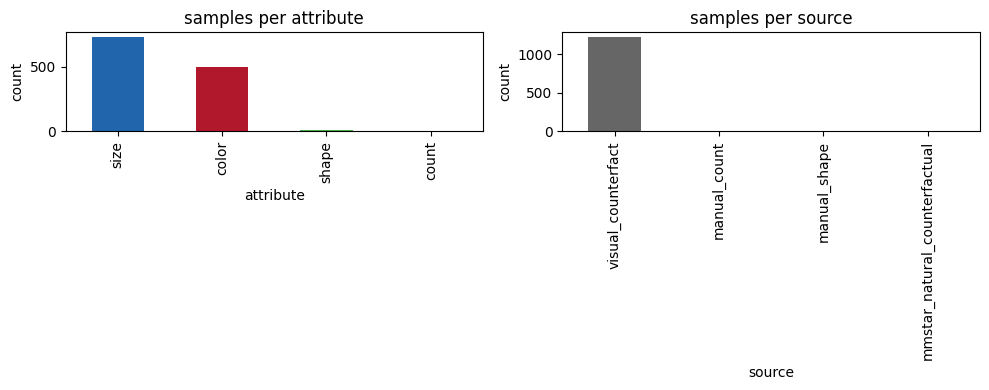

In [97]:
if META_PATH.exists():
    df = pd.read_csv(META_PATH)

    # per-attribute counts
    print("=" * 50)
    print("DATASET SUMMARY")
    print("=" * 50)
    attr_counts = df["attribute"].value_counts()
    for attr in ["color", "size", "count", "shape"]:
        n = attr_counts.get(attr, 0)
        status = "OK" if n > 0 else "MISSING"
        print(f"  {attr:8s}: {n:5d} samples  [{status}]")
    print(f"  {'TOTAL':8s}: {len(df):5d}")

    # source breakdown
    print(f"\nby source:")
    for src, cnt in df["source"].value_counts().items():
        print(f"  {src:25s}: {cnt}")

    # check for missing images
    missing_cf  = sum(1 for _, r in df.iterrows() if r["cf_image"] and not Path(r["cf_image"]).exists())
    missing_std = sum(1 for _, r in df.iterrows()
                      if pd.notna(r["std_image"]) and r["std_image"] != "" and not Path(r["std_image"]).exists())
    print(f"\nmissing counterfactual images: {missing_cf}")
    print(f"missing standard images: {missing_std}")

    # check for CHECK_MANUALLY entries
    manual_check = df[df["visual_answer"] == "CHECK_MANUALLY"]
    if len(manual_check) > 0:
        print(f"\nWARNING: {len(manual_check)} samples have visual_answer='CHECK_MANUALLY'")
        print("open metadata.csv and fill in the actual visual answers before Phase 3")

    # visualize distribution
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    attr_counts.plot.bar(ax=axes[0], color=["#2166AC", "#B2182B", "#4DAF4A", "#984EA3"])
    axes[0].set_title("samples per attribute")
    axes[0].set_ylabel("count")

    df["source"].value_counts().plot.bar(ax=axes[1], color="#666666")
    axes[1].set_title("samples per source")
    axes[1].set_ylabel("count")

    plt.tight_layout()
    plt.savefig(DATASET_DIR / "dataset_stats.png", dpi=110)
    plt.show()

else:
    print("metadata.csv not found — run Part 5 first")

In [96]:
df = pd.read_csv(META_PATH)
manual_rows = df[df["visual_answer"] == "CHECK_MANUALLY"]
print(manual_rows[["sample_id", "object", "cf_image"]])

    sample_id         object  \
0  count_0001   hand_fingers   
1  count_0002     car_wheels   
2  count_0003  traffic_light   
6  count_0001   hand_fingers   
7  count_0002     car_wheels   
8  count_0003  traffic_light   

                                            cf_image  
0  arbitration_dataset/images/count/count_0001_cf...  
1  arbitration_dataset/images/count/count_0002_cf...  
2  arbitration_dataset/images/count/count_0003_cf...  
6  arbitration_dataset/images/count/count_0001_cf...  
7  arbitration_dataset/images/count/count_0002_cf...  
8  arbitration_dataset/images/count/count_0003_cf...  


In [ ]:
#Debugging to check if manual check rows are missing

In [98]:
sample = [m for m in ALL_METADATA if m["attribute"] == "color"][0]
print(sample)

{'sample_id': 'color_0001', 'attribute': 'color', 'object': 'American chameleon', 'question': 'What color is the American chameleon?', 'visual_answer': '', 'prior_answer': '', 'cf_image': 'arbitration_dataset/images/color/color_0001_cf.png', 'std_image': 'arbitration_dataset/images/color/color_0001_std.png', 'source': 'visual_counterfact'}


In [103]:
import ast

def extract_answer(val):
    """Handle plain strings, real lists, and stringified lists like "['green']"."""
    if isinstance(val, (list, tuple)):
        val = val[0] if len(val) else ""
    val = str(val).strip()
    # catch stringified-list artifacts: "['green']" or '["green"]'
    if val.startswith("[") and val.endswith("]"):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple)) and len(parsed):
                val = str(parsed[0])
        except (ValueError, SyntaxError):
            val = val.strip("[]").strip("'\"")
    return val.lower().strip()

# quick self-test before trusting it on 1220 rows
assert extract_answer("['green']") == "green"
assert extract_answer(["white"]) == "white"
assert extract_answer("brown") == "brown"
print("extract_answer self-test PASSED")

extract_answer self-test PASSED


In [104]:
ALL_METADATA = [m for m in ALL_METADATA if m["source"] != "visual_counterfact"]
print(f"after clearing: {len(ALL_METADATA)} remain (should be 14)")

color_count = process_vc_split(vc_dataset["color"], "color", "What color is the {object}?")
size_count  = process_vc_split(vc_dataset["size"], "size", "Which is bigger, the {object}?")
print(f"reprocessed: Color={color_count}, Size={size_count}")

after clearing: 8 remain (should be 14)
reprocessed: Color=493, Size=727


In [105]:
# check EVERY entry for leftover brackets, not just eyeball one row
bad_rows = [m for m in ALL_METADATA
           if "[" in m["visual_answer"] or "[" in m["prior_answer"]]

print(f"rows with leftover bracket artifacts: {len(bad_rows)}")
if bad_rows:
    print("SAMPLE OF BROKEN ROWS:")
    for r in bad_rows[:5]:
        print(r)
    raise AssertionError("bracket artifacts still present — do not proceed to CSV write")

# check for any remaining empty answers
empty_rows = [m for m in ALL_METADATA if m["visual_answer"] == "" or m["prior_answer"] == ""]
print(f"rows with empty answers: {len(empty_rows)}")

sample = [m for m in ALL_METADATA if m["attribute"] == "color"][0]
print("\nverification sample:", sample)

if not bad_rows and not empty_rows:
    print("\nALL CHECKS PASSED — safe to write CSV")

rows with leftover bracket artifacts: 0
rows with empty answers: 0

verification sample: {'sample_id': 'color_0001', 'attribute': 'color', 'object': 'American chameleon', 'question': 'What color is the American chameleon?', 'visual_answer': 'brown', 'prior_answer': 'green', 'cf_image': 'arbitration_dataset/images/color/color_0001_cf.png', 'std_image': 'arbitration_dataset/images/color/color_0001_std.png', 'source': 'visual_counterfact'}

ALL CHECKS PASSED — safe to write CSV


In [101]:
sample = [m for m in ALL_METADATA if m["attribute"] == "color"][0]
print("verification sample:", sample)
assert sample["visual_answer"] != "", "STILL BROKEN : visual_answer is empty"
assert sample["prior_answer"] != "", "STILL BROKEN — prior_answer is empty"
print("\nPASSED — answers are populated correctly")

from collections import Counter
print(Counter((m["attribute"], m["source"]) for m in ALL_METADATA))

verification sample: {'sample_id': 'color_0001', 'attribute': 'color', 'object': 'American chameleon', 'question': 'What color is the American chameleon?', 'visual_answer': 'brown', 'prior_answer': "['green']", 'cf_image': 'arbitration_dataset/images/color/color_0001_cf.png', 'std_image': 'arbitration_dataset/images/color/color_0001_std.png', 'source': 'visual_counterfact'}

PASSED — answers are populated correctly
Counter({('size', 'visual_counterfact'): 727, ('color', 'visual_counterfact'): 493, ('count', 'manual_count'): 3, ('shape', 'manual_shape'): 3, ('shape', 'mmstar_natural_counterfactual'): 2})


In [108]:
fieldnames = ["sample_id", "attribute", "object", "question",
              "visual_answer", "prior_answer", "cf_image", "std_image", "source"]
df = pd.read_csv(META_PATH)

print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
for attr in ["color", "size", "count", "shape"]:
    n = (df["attribute"] == attr).sum()
    print(f"  {attr:8s}: {n:5d} samples")
print(f"  {'TOTAL':8s}: {len(df):5d}")

dupes = df.duplicated("sample_id").sum()
empty_va = (df["visual_answer"].astype(str).str.strip() == "").sum()
empty_pa = (df["prior_answer"].astype(str).str.strip() == "").sum()
bracket_artifacts = df["visual_answer"].astype(str).str.contains(r"\[").sum() + df["prior_answer"].astype(str).str.contains(r"\[").sum()

print(f"\nduplicate sample_ids: {dupes}")
print(f"empty visual_answer: {empty_va}")
print(f"empty prior_answer: {empty_pa}")
print(f"bracket artifacts: {bracket_artifacts}")

FINAL DATASET SUMMARY
  color   :   493 samples
  size    :   727 samples
  count   :     3 samples
  shape   :     5 samples
  TOTAL   :  1228

duplicate sample_ids: 0
empty visual_answer: 0
empty prior_answer: 0
bracket artifacts: 0


In [109]:
print(f"total count samples: {len(count_samples)}")
print("=" * 70)
for i, row in enumerate(count_samples):
    print(f"[{i}] Q: {row['question']}")
    print(f"     A: {row.get('answer')}")
    print()

total count samples: 160
[0] Q: How many times is the object 'tree' detected in the attribute detections?
Options: A: Two, B: Three, C: Four, D: Five
     A: B

[1] Q: How many different "pointed" kinds are there?
Options: A: 2, B: 4, C: 1, D: 3
     A: A

[2] Q: How many police officers are in the image?
Options: A: 1, B: 0, C: 2, D: 3
     A: A

[3] Q: How many people are playing music in the image?
Options: A: One, B: Two, C: Three, D: Four
     A: D

[4] Q: How many windows are in the living room?
Options: A: One, B: Four, C: Three, D: Two
     A: C

[5] Q: How many boats are in the image?
Options: A: Two, B: One, C: Three, D: Four
     A: D

[6] Q: How many gloves can be seen in this image?
Options: A: One, B: Two, C: Three, D: Four
     A: C

[7] Q: How many people are playing guitar in the image?
Options: A: One, B: Two, C: Three, D: Four
     A: C

[8] Q: How many chairs are there on the balcony in the image?
Options: A: 1, B: 3, C: 2, D: 4
     A: B

[9] Q: How many tree stump

In [110]:
print(f"total shape samples: {len(shape_samples)}")
print("=" * 70)
for i, row in enumerate(shape_samples):
    print(f"[{i}] Q: {row['question']}")
    print(f"     A: {row.get('answer')}")
    print()

total shape samples: 89
[0] Q: What is the main feature in the background of the image?
Options: A: A park bench near the water., B: A couple sitting on a bench., C: A body of water and the Golden Gate Bridge., D: A mountain in the distance.
     A: B

[1] Q: What is the center of focus in the image?
Options: A: A man writing in a book, B: A boy with his head in his hands surrounded by books, C: A cluttered desk with books and a pen, D: A stack of books covering a young man's face
     A: A

[2] Q: What object dominates the image in the foreground?
Options: A: A rocky and grassy field, B: Hills in the distance, C: A dirt road leading up a grassy hill to a rocky path, D: A large grey rock
     A: C

[3] Q: What is the main focus of the image?
Options: A: the woman's phone, B: the woman's hairstyle, C: the woman's sweater, D: the background scenery
     A: B

[4] Q: What is the overall scene depicted in this image?
Options: A: A group of people ice skating on a frozen lake surrounded by 

In [112]:
#filter MMStar for real color questions (whole dataset

In [116]:
(IMAGES_DIR / "mmstar_color").mkdir(parents=True, exist_ok=True)

In [117]:
import re, random

def is_color_question(question):
    q = str(question).lower()
    return "color" in q or "colour" in q

def extract_object_from_color_question(question):
    q = str(question).lower()
    patterns = [
        r"color of the ([\w\s]+?)(?:\s+in\b|\s+on\b|\?|$)",
        r"colou?r is the ([\w\s]+?)(?:\s+in\b|\s+on\b|\?|$)",
        r"colou?r are the ([\w\s]+?)(?:\s+in\b|\s+on\b|\?|$)",
    ]
    for pat in patterns:
        m = re.search(pat, q)
        if m:
            return m.group(1).strip()
    return "object"

# scan the ENTIRE MMStar dataset (not just count/shape categories) for color questions
mmstar_color_samples = []
for i in range(len(mmstar)):
    row = mmstar[i]
    if is_color_question(row.get("question", "")):
        mmstar_color_samples.append(row)

print(f"found {len(mmstar_color_samples)} color-related samples across all of MMStar")

# preview a few
for row in mmstar_color_samples[:10]:
    print(f"  A: {row.get('answer')}  Q: {row['question'][:70]}")

found 139 color-related samples across all of MMStar
  A: C  Q: What is the main color scheme of the image?
Options: A: Shades of blue
  A: D  Q: What is the dominant color in the image?
Options: A: Red, B: Blue, C: 
  A: A  Q: What is the dominant color in the image?
Options: A: White, B: Blue, C
  A: B  Q: What is the predominant color in this image?
Options: A: Blue, B: Whit
  A: A  Q: which image is more colorful?
Options: A: The first image, B: The seco
  A: A  Q: What color dominates the logo seen on the wall?
Options: A: Red, B: Bl
  A: D  Q: What is the main color of the image?
Options: A: Red, B: Green, C: Bla
  A: D  Q: What is the main color scheme of this image?
Options: A: Black and sil
  A: B  Q: What is the prominent color in the image?
Options: A: Blue, B: Green, 
  A: B  Q: What is the dominant color in the image?
Options: A: Yellow, B: Black,


In [118]:
# counterfactuals from every match

In [119]:
AVAILABLE_COLORS = list(TARGET_HUE_PIL.keys())
random.seed(42)  # reproducible color assignment

def pick_different_color(original_color, all_colors):
    orig_lower = str(original_color).lower().strip()
    candidates = [c for c in all_colors if c != orig_lower]
    return random.choice(candidates) if candidates else "blue"

mmstar_color_registered = 0

for row in mmstar_color_samples:
    obj_name = extract_object_from_color_question(row["question"])
    prior_color = str(row.get("answer", "")).lower().strip()

    # skip if the answer isn't actually a colour word we recognise
    # (some MMStar answers are letters like "A" if it's multiple-choice with color options embedded)
    if prior_color not in AVAILABLE_COLORS and len(prior_color) > 15:
        continue  # likely not a clean colour answer, skip

    std_img = row.get("image")
    if std_img is None:
        continue

    # if the answer wasn't a clean recognised colour word, still try — default handling
    if prior_color not in AVAILABLE_COLORS:
        # try to match common variants
        color_aliases = {"grey": "gray", "brown": "brown", "tan": "brown"}
        prior_color = color_aliases.get(prior_color, "brown")  # fallback default

    target_color = pick_different_color(prior_color, AVAILABLE_COLORS)
    cf_img = recolor_to_target(std_img, target_color)

    sid = f"mmstar_color_{mmstar_color_registered + 1:04d}"
    cf_path = save_image(cf_img, IMAGES_DIR / "mmstar_color" / f"{sid}_cf.png")
    std_path = save_image(std_img.convert("RGB"), IMAGES_DIR / "mmstar_color" / f"{sid}_std.png")

    register_sample(
        sid, "mmstar_color", obj_name,
        f"What color is the {obj_name}?",
        visual_answer=target_color,
        prior_answer=prior_color,
        cf_image_path=cf_path,
        std_image_path=std_path,
        source="mmstar_recolor"
    )
    mmstar_color_registered += 1

print(f"mmstar_color samples registered: {mmstar_color_registered}")

mmstar_color samples registered: 139


In [120]:
ALL_METADATA = [m for m in ALL_METADATA if m["source"] != "mmstar_recolor"]
print(f"cleared broken entries, {len(ALL_METADATA)} remain")

cleared broken entries, 1228 remain


In [123]:
import re, random

TARGET_HUE_PIL = {
    "red": 0, "orange": 21, "yellow": 42, "green": 85,
    "blue": 150, "purple": 200, "pink": 225, "brown": 15,
}
ALL_TARGET_COLORS = list(TARGET_HUE_PIL.keys()) + ["white", "black", "gray"]

def recolor_to_target(img, target_name):
    """Recolor via hue-rotation for chromatic colors, brightness/saturation shift for white/black/gray."""
    if target_name in TARGET_HUE_PIL:
        hsv = np.asarray(img.convert("HSV")).astype(np.float64)
        h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
        mask = (s > 40) & (v > 30) & (v < 250)
        if mask.sum() == 0:
            orig_hue = float(h.mean())
        else:
            hist, edges = np.histogram(h[mask], bins=32, range=(0, 256))
            peak = np.argmax(hist)
            lo, hi = edges[max(peak-1,0)], edges[min(peak+2,32)]
            refined = h[mask][(h[mask] >= lo) & (h[mask] < hi)]
            ang = refined / 256 * 2 * np.pi
            mean_ang = np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())
            orig_hue = (mean_ang / (2*np.pi) * 256) % 256
        shift = (TARGET_HUE_PIL[target_name] - orig_hue) % 256
        hsv_int = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv_int[..., 0] = (hsv_int[..., 0] + int(shift)) % 256
        return Image.fromarray(hsv_int.astype(np.uint8), "HSV").convert("RGB")
    elif target_name == "white":
        hsv = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv[..., 1] = (hsv[..., 1] * 0.15).astype(np.int16)
        hsv[..., 2] = np.clip(hsv[..., 2] * 1.6, 0, 255).astype(np.int16)
        return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    elif target_name == "black":
        hsv = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv[..., 2] = np.clip(hsv[..., 2] * 0.15, 0, 255).astype(np.int16)
        return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    elif target_name == "gray":
        hsv = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv[..., 1] = (hsv[..., 1] * 0.1).astype(np.int16)
        return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    else:
        raise ValueError(f"unknown target color: {target_name}")

def clean_color_word(text):
    text = str(text).lower().strip()
    for c in ALL_TARGET_COLORS:
        if c in text:
            return c
    aliases = {"grey": "gray", "tan": "brown", "beige": "brown", "silver": "gray", "blond": "yellow"}
    for alias, mapped in aliases.items():
        if alias in text:
            return mapped
    return None

In [124]:
def pick_different_color(original_color, all_colors):
    orig = str(original_color).lower().strip()
    candidates = [c for c in all_colors if c != orig]
    return random.choice(candidates) if candidates else "blue"

(IMAGES_DIR / "mmstar_color").mkdir(parents=True, exist_ok=True)
random.seed(42)

mmstar_color_registered = 0
skipped_no_color = 0

for row in mmstar_color_samples:
    obj_name = extract_object_from_color_question(row["question"])
    resolved = resolve_answer_letter(row)
    prior_color = clean_color_word(resolved)

    if prior_color is None:
        skipped_no_color += 1
        continue  # couldn't identify a clean recognised colour

    std_img = row.get("image")
    if std_img is None:
        continue

    target_color = pick_different_color(prior_color, ALL_TARGET_COLORS)
    cf_img = recolor_to_target(std_img, target_color)

    sid = f"mmstar_color_{mmstar_color_registered + 1:04d}"
    cf_path = save_image(cf_img, IMAGES_DIR / "mmstar_color" / f"{sid}_cf.png")
    std_path = save_image(std_img.convert("RGB"), IMAGES_DIR / "mmstar_color" / f"{sid}_std.png")

    register_sample(
        sid, "mmstar_color", obj_name,
        f"What color is the {obj_name}?",
        visual_answer=target_color,
        prior_answer=prior_color,
        cf_image_path=cf_path,
        std_image_path=std_path,
        source="mmstar_recolor"
    )
    mmstar_color_registered += 1

print(f"mmstar_color samples registered: {mmstar_color_registered}")
print(f"skipped (unrecognised colour): {skipped_no_color}")

mmstar_color samples registered: 53
skipped (unrecognised colour): 0


In [122]:
ALL_METADATA = [m for m in ALL_METADATA if m["source"] != "mmstar_recolor"]
print(f"cleared broken entries, {len(ALL_METADATA)} remain")

cleared broken entries, 1228 remain


In [125]:
mmstar_color_entries = [m for m in ALL_METADATA if m["source"] == "mmstar_recolor"]
print(f"total: {len(mmstar_color_entries)}")
for e in mmstar_color_entries[:15]:
    print(f"  object='{e['object']:30s}' visual={e['visual_answer']:8s} prior={e['prior_answer']:8s}")

total: 53
  object='majority of objects           ' visual=orange   prior=white   
  object='sheep                         ' visual=red      prior=brown   
  object='walls                         ' visual=blue     prior=brown   
  object='roof of the building          ' visual=green    prior=white   
  object='shirt worn by the baseball player standing' visual=green    prior=white   
  object='awning                        ' visual=yellow   prior=black   
  object='sandals                       ' visual=orange   prior=brown   
  object='object                        ' visual=black    prior=yellow  
  object='sand                          ' visual=orange   prior=brown   
  object='couch                         ' visual=gray     prior=brown   
  object='couch                         ' visual=pink     prior=brown   
  object='ears                          ' visual=red      prior=white   
  object='watch worn by a person        ' visual=red      prior=black   
  object='horse              

In [126]:
fieldnames = ["sample_id", "attribute", "object", "question",
              "visual_answer", "prior_answer", "cf_image", "std_image", "source"]

with open(META_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(ALL_METADATA)

print(f"metadata.csv written: {len(ALL_METADATA)} samples")

metadata.csv written: 1281 samples


In [127]:
ALL_METADATA = [m for m in ALL_METADATA
               if not (m["source"] == "mmstar_recolor" and "majority" in m["object"])]
print(f"after dropping aggregate-scene entries: {len(ALL_METADATA)}")

after dropping aggregate-scene entries: 1280


In [128]:
fieldnames = ["sample_id", "attribute", "object", "question",
              "visual_answer", "prior_answer", "cf_image", "std_image", "source"]

with open(META_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(ALL_METADATA)

print(f"metadata.csv written: {len(ALL_METADATA)} samples")

metadata.csv written: 1280 samples


In [129]:
import shutil
shutil.make_archive("arbitration_dataset", "zip", DATASET_DIR.parent, DATASET_DIR.name)
print("zipped: arbitration_dataset.zip")

zipped: arbitration_dataset.zip


In [130]:
import os
print(os.path.abspath("arbitration_dataset.zip"))

/Users/ramangudewar/Seminar-MLU/FIanal Project/arbitration_dataset.zip


In [131]:
df = pd.read_csv(META_PATH)

print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
for attr in ["color", "size", "count", "shape", "mmstar_color"]:
    n = (df["attribute"] == attr).sum()
    print(f"  {attr:14s}: {n:5d} samples")
print(f"  {'TOTAL':14s}: {len(df):5d}")

print(f"\nby source:")
for src, cnt in df["source"].value_counts().items():
    print(f"  {src:25s}: {cnt}")

dupes = df.duplicated("sample_id").sum()
empty_va = (df["visual_answer"].astype(str).str.strip() == "").sum()
empty_pa = (df["prior_answer"].astype(str).str.strip() == "").sum()

print(f"\nduplicate sample_ids: {dupes}")
print(f"empty visual_answer: {empty_va}")
print(f"empty prior_answer: {empty_pa}")

FINAL DATASET SUMMARY
  color         :   493 samples
  size          :   727 samples
  count         :     3 samples
  shape         :     5 samples
  mmstar_color  :    52 samples
  TOTAL         :  1280

by source:
  visual_counterfact       : 1220
  mmstar_recolor           : 52
  manual_count             : 3
  manual_shape             : 3
  mmstar_natural_counterfactual: 2

duplicate sample_ids: 0
empty visual_answer: 0
empty prior_answer: 0


In [ ]:
#DONE

In [94]:
fieldnames = ["sample_id", "attribute", "object", "question",
              "visual_answer", "prior_answer", "cf_image", "std_image", "source"]

with open(META_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(ALL_METADATA)

print(f"metadata.csv written: {len(ALL_METADATA)} samples")

metadata.csv written: 1234 samples
